## 0 · Setup

In [1]:
import sys, json, platform
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib; import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "reference_code"))
import master_paper_lib as M
import curated_paths as CP

OUT = M.OUT                      # analysis_outputs/master_paper
FIGS = OUT / "figures"; FIGS.mkdir(parents=True, exist_ok=True)
OUT.mkdir(parents=True, exist_ok=True)

REPEAT_SEEDS = M.REPEAT_SEEDS    # [42, 101, 202, 303, 404]
MLP_SEEDS    = M.MLP_SEEDS       # [42, 123, 7, 13, 21]
print("repeat seeds:", REPEAT_SEEDS, "| mlp seeds:", MLP_SEEDS)
print("outputs ->", OUT)

repeat seeds: [42, 101, 202, 303, 404] | mlp seeds: [42, 123, 7, 13, 21]
outputs -> /Users/maiakaplan/Documents/evo2/nn_project/analysis_outputs/master_paper


## 1 · Data & quality control

In [ ]:
man, fasta, per_base, collisions, n_collision_groups = M.load_inputs(require_nll=True)
print(f"references (FASTA): {len(fasta):,} | scored reads: {len(per_base):,}")
print(f"label-collision groups (dropped): {n_collision_groups}  ({len(collisions)} reads)")

# Build one frame (seed 42 == original v2) for QC / counts
v2_42 = M.make_repeated_splits([42])[42]
M.assert_atomic(v2_42)
df = M.build_frame(per_base, v2_42, collisions)

neg_n = int((~df["is_pos"]).sum())
qc = []
for r in CP.RANK_ORDER:
    if r in set(df["rank"]):
        npos = int(((df.is_pos) & (df["rank"] == r)).sum())
        qc.append({"rank": r, "n_pos": npos, "n_neg_pool": neg_n,
                   "prevalence_vs_pool": round(npos/(npos+neg_n), 4)})
qc = pd.DataFrame(qc); qc.to_csv(OUT / "qc_table.csv", index=False)
print(f"\nrows after filters: {len(df):,} | negative pool: {neg_n:,}")
qc

references (FASTA): 56,127 | scored reads: 56,127
label-collision groups (dropped): 8  (46 reads)


references: 159 | sequence clusters: 159



rows after filters: 36,780 | negative pool: 25,658


,rank,n_pos,n_neg_pool,prevalence_vs_pool
0,Species,1582,25658,0.0581
1,Genus,1590,25658,0.0584
2,Family,1590,25658,0.0584
3,Order,1590,25658,0.0584
4,Phylum,1590,25658,0.0584
5,Novelty,1590,25658,0.0584
6,Noise,1590,25658,0.0584


## 2 · Splits & leakage control

In [3]:
splits = M.make_repeated_splits(REPEAT_SEEDS)
rep_rows = []
for s, v2 in splits.items():
    M.assert_atomic(v2)                      # raises if any cluster leaks
    v2.to_csv(OUT / f"split_v2_seed{s}.csv", index=False)
    rep_rows.append({"repeat_seed": s, "boundary_dropped": int(v2.boundary.sum()),
                     "fold_sizes": dict(v2[~v2.boundary].groupby("fold").size())})
print("all repeats verified cluster-atomic ✓")
pd.DataFrame(rep_rows)

references: 159 | sequence clusters: 159


all repeats verified cluster-atomic ✓


,repeat_seed,boundary_dropped,fold_sizes
0,42,7719,"{0: 9732, 1: 9738, 2: 9753, 3: 9756, 4: 9429}"
1,101,7719,"{0: 9732, 1: 9738, 2: 9753, 3: 9756, 4: 9429}"
2,202,7719,"{0: 9732, 1: 9738, 2: 9753, 3: 9756, 4: 9429}"
3,303,7719,"{0: 9732, 1: 9738, 2: 9753, 3: 9756, 4: 9429}"
4,404,7719,"{0: 9732, 1: 9738, 2: 9753, 3: 9756, 4: 9429}"


## 3 · Metrics 

- **AUROC** — threshold-free ranking quality; prevalence-independent → our headline comparator.
- **AP (average precision)** — area under precision–recall; **prevalence-sensitive**, the honest metric when
  positives are rare. Its random baseline ≈ prevalence (~5.8% here), drawn on every AP panel.
- **Why not accuracy** — at ~5.8% prevalence "predict all negative" scores ~94% and is useless.
- **Error bar** — mean ± SD across the repeated-CV replicates (n in each table/caption).

## 4 · The model ladder under repeated CV

Capability ladder: scalar `mean_nll` → scalar `std_nll` → full 311-profile `logistic` → tiny `MLP`.

In [ ]:
# --- Deterministic ladder 
det_rows = []
for s, v2 in splits.items():
    dfi = M.build_frame(per_base, v2, collisions)
    for r in CP.ALL_POS_RANKS:
        if CP.primary_cohort(r) in set(dfi["cohort"]):
            rr = M.eval_deterministic(dfi, r)
            for x in rr: x["repeat_seed"] = s
            det_rows += rr
det = pd.DataFrame(det_rows)
print("deterministic replicate rows:", len(det))
det.head()

deterministic replicate rows: 525


,rank,fold,test_n,test_pos,prevalence,model,seed,auroc,ap,repeat_seed
0,Species,0,5468,317,0.057974,mean_nll,-1,0.499527,0.055568,42
1,Species,0,5468,317,0.057974,std_nll,-1,0.598650,0.087717,42
2,Species,0,5468,317,0.057974,logistic_profile,-1,0.597413,0.077990,42
3,Species,1,5473,317,0.057921,mean_nll,-1,0.480951,0.051461,42
4,Species,1,5473,317,0.057921,std_nll,-1,0.574047,0.081865,42


In [ ]:
# --- Tiny MLP 
mlp_path = OUT / "mlp_folds_repeated.csv"
try:
    import torch  # noqa: F401
    mlp_rows = []
    for s, v2 in splits.items():
        dfi = M.build_frame(per_base, v2, collisions)
        for r in CP.ALL_POS_RANKS:
            if CP.primary_cohort(r) in set(dfi["cohort"]):
                rr = M.eval_mlp(dfi, r, seeds=MLP_SEEDS)
                for x in rr: x["repeat_seed"] = s
                mlp_rows += rr
    mlp = pd.DataFrame(mlp_rows); mlp.to_csv(mlp_path, index=False)
    print(f"MLP replicate rows: {len(mlp)}  (saved -> {mlp_path.name})")
except ImportError:
    if mlp_path.exists():
        mlp = pd.read_csv(mlp_path); print(f"torch absent — reusing saved MLP rows ({len(mlp)}).")
    else:
        mlp = pd.DataFrame(); print("torch absent and no saved MLP rows — run this cell on the M4.")

MLP replicate rows: 875  (saved -> mlp_folds_repeated.csv)


In [ ]:
# --- Tiny CNN : avg & max pool at the two HARD ranks (Species, Genus), repeated CV ---
cnn_path = OUT / "cnn_pooling_folds_repeated.csv"
try:
    import torch  # noqa: F401
    cnn_rows = []
    for s, v2 in splits.items():
        dfi = M.build_frame(per_base, v2, collisions)
        for rk in ["Species", "Genus"]:
            for pool in ["avg", "max"]:
                rr = M.eval_cnn(dfi, rk, pool=pool, seeds=MLP_SEEDS)
                for x in rr: x["repeat_seed"] = s
                cnn_rows += rr
    cnn = pd.DataFrame(cnn_rows); cnn.to_csv(cnn_path, index=False)
    print(f"CNN replicate rows: {len(cnn)} (saved -> {cnn_path.name})")
except ImportError:
    cnn = pd.read_csv(cnn_path) if cnn_path.exists() else pd.DataFrame()
    print("torch absent — CNN skipped." + (f" Reusing {len(cnn)} saved rows." if len(cnn) else ""))

CNN replicate rows: 500 (saved -> cnn_pooling_folds_repeated.csv)


In [7]:
# --- Combine, summarise (mean ± SD over replicates), save ---
folds = pd.concat([det, mlp], ignore_index=True) if len(mlp) else det.copy()
folds.to_csv(OUT / "per_rank_folds_repeated.csv", index=False)
summary = M.summarize(folds)
summary.to_csv(OUT / "per_rank_summary.csv", index=False)

def fmt(d, col):
    return d[f"{col}_mean"].round(3).astype(str) + " ± " + d[f"{col}_sd"].round(3).astype(str)
view = summary.copy()
view["AUROC"] = fmt(view, "auroc"); view["AP"] = fmt(view, "ap")
view[["model","rank","AUROC","AP","n_replicates"]]

,model,rank,AUROC,AP,n_replicates
0,logistic_profile,Species,0.605 ± 0.011,0.083 ± 0.004,25
1,logistic_profile,Genus,0.79 ± 0.017,0.264 ± 0.066,25
2,logistic_profile,Family,0.914 ± 0.02,0.54 ± 0.146,25
3,logistic_profile,Order,0.966 ± 0.012,0.748 ± 0.149,25
4,logistic_profile,Phylum,0.994 ± 0.006,0.919 ± 0.094,25
5,logistic_profile,Novelty,0.999 ± 0.001,0.988 ± 0.015,25
6,logistic_profile,Noise,1.0 ± 0.0,0.998 ± 0.003,25
7,mean_nll,Species,0.486 ± 0.009,0.052 ± 0.002,25
8,mean_nll,Genus,0.739 ± 0.014,0.119 ± 0.005,25
9,mean_nll,Family,0.88 ± 0.018,0.323 ± 0.048,25


## 5 · Figures 

All generated here from the summary above. Saved to `analysis_outputs/master_paper/figures/`.

### Fig 1 — per-base perplexity profiles (novelty gradient vs contamination)


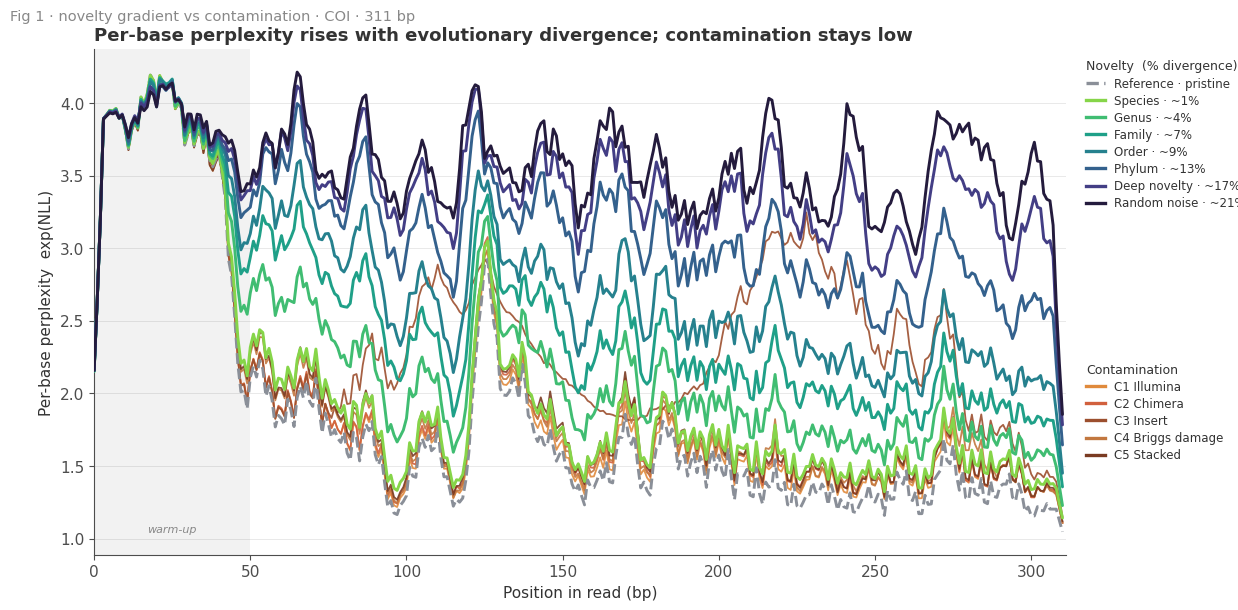

In [8]:
# Fig 1 — per-base perplexity: novelty divergence gradient vs contamination (overlaid)
from matplotlib.lines import Line2D
WARMUP, NPOS, SMOOTH = 50, CP.NLL_LEN, 7

def _cohort_of(c):
    return "C4_briggs" if str(c).startswith("C4_briggs") else c

NOV = [  # (cohort, label, realized mean % divergence)
    ("C0_REF",             "Reference · pristine", None),
    ("C6_pyvolve_Species", "Species · ~1%",   1),
    ("C6_pyvolve_Genus",   "Genus · ~4%",     4),
    ("C6_pyvolve_Family",  "Family · ~7%",    7),
    ("C6_pyvolve_Order",   "Order · ~9%",     9),
    ("C6_pyvolve_Phylum",  "Phylum · ~13%",   13),
    ("C6_pyvolve_Novelty", "Deep novelty · ~17%", 17),
    ("C6_pyvolve_Noise",   "Random noise · ~21%", 21),
]
CON = [("C1_illumina","C1 Illumina"),("C2_chimera","C2 Chimera"),("C3_insert","C3 Insert"),
       ("C4_briggs","C4 Briggs damage"),("C5_stacked","C5 Stacked")]
_grad = plt.cm.viridis(np.linspace(0.82, 0.18, 6))
NOV_COLOR = {"C0_REF":"#8a8f98","C6_pyvolve_Species":_grad[0],"C6_pyvolve_Genus":_grad[1],
             "C6_pyvolve_Family":_grad[2],"C6_pyvolve_Order":_grad[3],"C6_pyvolve_Phylum":_grad[4],
             "C6_pyvolve_Novelty":_grad[5],"C6_pyvolve_Noise":"#241b3d"}
CON_COLOR = {"C1_illumina":"#e08a3c","C2_chimera":"#d1603d","C3_insert":"#9c4f2e",
             "C4_briggs":"#c2773f","C5_stacked":"#7a3b22"}

_man = man.assign(_g=man["cohort"].map(_cohort_of))
def _profile(key):
    arrs = []
    for sid in _man.loc[_man._g == key, "seq_id"]:
        nll = per_base.get(sid)
        if nll is None: continue
        a = np.full(NPOS, np.nan); n = min(len(nll), NPOS); a[:n] = nll[:n]; arrs.append(a)
    Mx = np.vstack(arrs)
    sm = lambda y: np.convolve(y, np.ones(SMOOTH)/SMOOTH, mode="same")
    return np.exp(sm(np.nanmean(Mx, 0)))

plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","axes.edgecolor":"#4d4d4d",
    "axes.linewidth":0.8,"font.size":11,"axes.labelsize":11,"xtick.color":"#4d4d4d",
    "ytick.color":"#4d4d4d","axes.labelcolor":"#333","text.color":"#333"})

fig, ax = plt.subplots(figsize=(14.5, 6.4))
h_nov, h_con = [], []
for key, lab, _ in NOV:
    col = NOV_COLOR[key]; ls = "--" if key == "C0_REF" else "-"
    ax.plot(range(NPOS), _profile(key), color=col, lw=2.1, ls=ls, solid_capstyle="round", zorder=3)
    h_nov.append(Line2D([0],[0], color=col, lw=2.4, ls=ls, label=lab))
for key, lab in CON:
    col = CON_COLOR[key]
    ax.plot(range(NPOS), _profile(key), color=col, lw=1.3, alpha=0.9, zorder=2)
    h_con.append(Line2D([0],[0], color=col, lw=2.4, label=lab))

ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
ax.yaxis.grid(True, color="#cccccc", lw=0.6, alpha=0.5); ax.set_axisbelow(True)
ax.axvspan(0, WARMUP, color="#000000", alpha=0.05, lw=0)
ax.text(WARMUP/2, ax.get_ylim()[0]+0.04*np.ptp(ax.get_ylim()), "warm-up",
        ha="center", va="bottom", fontsize=8, style="italic", color="#888")
ax.set_xlim(0, NPOS); ax.set_xlabel("Position in read (bp)")
ax.set_ylabel("Per-base perplexity  exp(NLL)")
ax.set_title("Per-base perplexity rises with evolutionary divergence; contamination stays low",
             loc="left", weight="bold", fontsize=13)
fig.text(0.012, 0.945, "Fig 1 · novelty gradient vs contamination · COI · 311 bp",
         fontsize=10.5, color="#888")
leg1 = ax.legend(handles=h_nov, title="Novelty  (% divergence)", loc="upper left",
                 bbox_to_anchor=(1.01, 1.0), fontsize=8.5, title_fontsize=9, frameon=False,
                 labelspacing=0.35, handlelength=1.6); leg1._legend_box.align = "left"
ax.add_artist(leg1)
leg2 = ax.legend(handles=h_con, title="Contamination", loc="upper left",
                 bbox_to_anchor=(1.01, 0.40), fontsize=8.5, title_fontsize=9, frameon=False,
                 labelspacing=0.35, handlelength=1.6); leg2._legend_box.align = "left"
fig.subplots_adjust(left=0.07, right=0.74, top=0.9, bottom=0.11)
fig.savefig(FIGS / "fig1_perbase_perplexity.png", dpi=200, bbox_inches="tight"); plt.show()

In [9]:
# --- shared figure style for the report set (Figs 2–5; Fig 1 is self-styled) ---
import matplotlib as mpl
mpl.rcParams.update({
    "figure.facecolor":"white","axes.facecolor":"white","axes.edgecolor":"#4d4d4d",
    "axes.linewidth":0.8,"font.size":11,"axes.titlesize":12,"axes.labelsize":11,
    "xtick.color":"#4d4d4d","ytick.color":"#4d4d4d","axes.labelcolor":"#333","text.color":"#333",
    "legend.frameon":False,
})
# rank gradient consistent with Fig 1 (Species green -> deep purple)
_RANKS = ["Species","Genus","Family","Order","Phylum","Novelty","Noise"]
_g7 = plt.cm.viridis(np.linspace(0.82, 0.12, 7))
RANK_COLOR = {r: _g7[i] for i, r in enumerate(_RANKS)}
RANK_COLOR["Novelty"] = "#3b2370"; RANK_COLOR["Noise"] = "#241b3d"
def despine(ax):
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    ax.yaxis.grid(True, color="#cccccc", lw=0.6, alpha=0.5); ax.set_axisbelow(True)

### Fig 2 — mean-NLL overlap histograms 

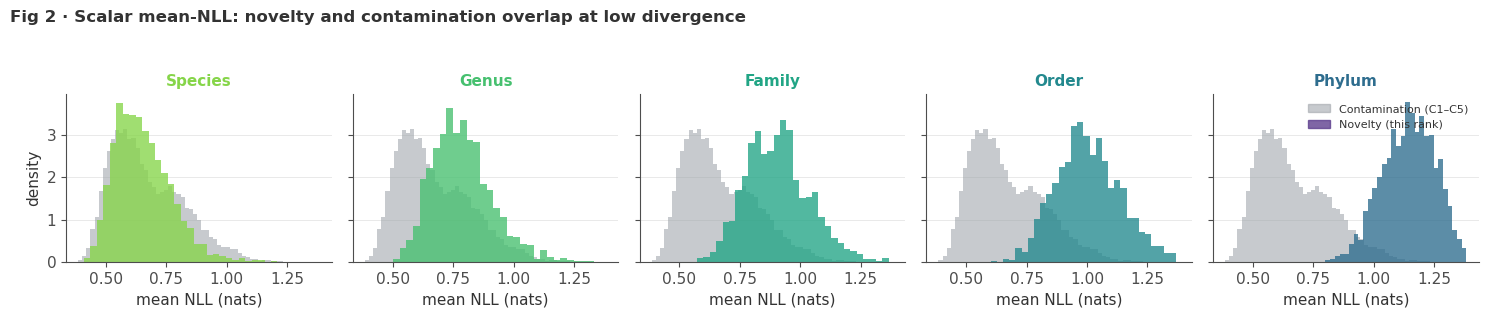

In [10]:
# Fig 2 — mean-NLL overlap histograms: a scalar can't separate near-novelty from contamination
show = [r for r in ["Species","Genus","Family","Order","Phylum"] if r in set(df["rank"])]
neg = df[~df.is_pos]["mean_nll"].to_numpy()
fig, axes = plt.subplots(1, len(show), figsize=(3.0*len(show), 3.2), sharey=True, sharex=True)
axes = np.atleast_1d(axes)
for ax, r in zip(axes, show):
    pos = df[(df.is_pos) & (df["rank"]==r)]["mean_nll"].to_numpy()
    ax.hist(neg, bins=50, density=True, color="#9aa0a6", alpha=0.55)
    ax.hist(pos, bins=30, density=True, color=RANK_COLOR[r], alpha=0.78)
    despine(ax); ax.set_title(r, fontsize=11, weight="bold", color=RANK_COLOR[r])
    ax.set_xlabel("mean NLL (nats)")
axes[0].set_ylabel("density")
from matplotlib.patches import Patch
axes[-1].legend(handles=[Patch(color="#9aa0a6", alpha=0.55, label="Contamination (C1–C5)"),
                         Patch(color="#5b3b8c", alpha=0.78, label="Novelty (this rank)")],
                fontsize=8, loc="upper right")
fig.suptitle("Fig 2 · Scalar mean-NLL: novelty and contamination overlap at low divergence",
             x=0.01, ha="left", weight="bold", fontsize=12)
fig.tight_layout(rect=[0,0,1,0.93])
fig.savefig(FIGS / "fig2_mean_nll_overlap.png", dpi=200, bbox_inches="tight"); plt.show()

### Fig 3 — per-rank detection boundary (AUROC)

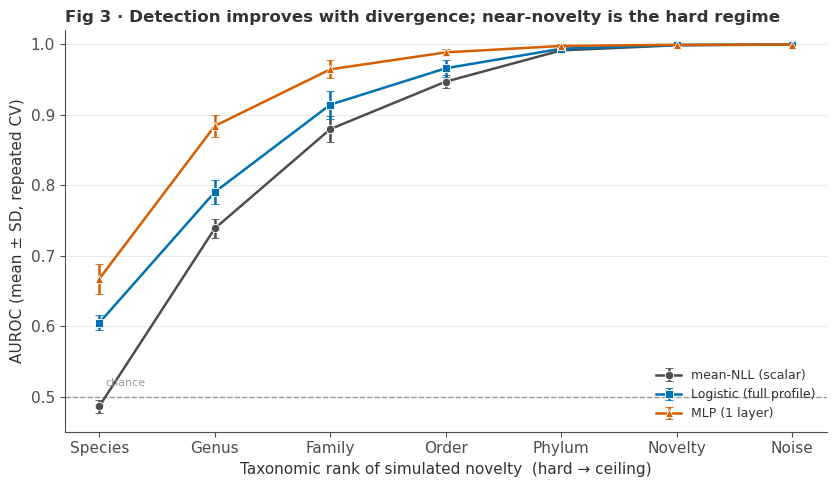

In [11]:
# Fig 3 — per-rank AUROC boundary curve (std_nll dropped)
ranks = [r for r in CP.RANK_ORDER if r in set(summary["rank"].astype(str))]
order = ["mean_nll", "logistic_profile", "tiny_mlp"]          # std_nll intentionally dropped
MCOL  = {"mean_nll":"#4D4D4D", "logistic_profile":"#0072B2", "tiny_mlp":"#D55E00"}  # Okabe–Ito
MMARK = {"mean_nll":"o", "logistic_profile":"s", "tiny_mlp":"^"}
MLAB = {"mean_nll":"mean-NLL (scalar)", "logistic_profile":"Logistic (full profile)", "tiny_mlp":"MLP (1 layer)"}
fig, ax = plt.subplots(figsize=(8.5, 5))
for mdl in [m for m in order if m in set(summary.model)]:
    sub = summary[summary.model==mdl].set_index(summary[summary.model==mdl]["rank"].astype(str))
    y = [sub.loc[r,"auroc_mean"] if r in sub.index else np.nan for r in ranks]
    e = [sub.loc[r,"auroc_sd"]   if r in sub.index else np.nan for r in ranks]
    ax.errorbar(ranks, y, yerr=e, marker=MMARK[mdl], markersize=6, capsize=3, lw=1.8,
                color=MCOL[mdl], markeredgecolor="white", markeredgewidth=0.6, label=MLAB[mdl])
ax.axhline(0.5, ls="--", c="#999", lw=1)
ax.text(0.05, 0.512, "chance", color="#999", fontsize=8, va="bottom", ha="left")
despine(ax)
ax.set_xlabel("Taxonomic rank of simulated novelty  (hard → ceiling)")
ax.set_ylabel("AUROC (mean ± SD, repeated CV)"); ax.set_ylim(0.45, 1.02)
ax.set_title("Fig 3 · Detection improves with divergence; near-novelty is the hard regime",
             loc="left", weight="bold")
ax.legend(loc="lower right", fontsize=9)
fig.tight_layout(); fig.savefig(FIGS / "fig3_per_rank_auroc.png", dpi=200, bbox_inches="tight"); plt.show()

### Fig 4 — capacity ladder at the two hard ranks

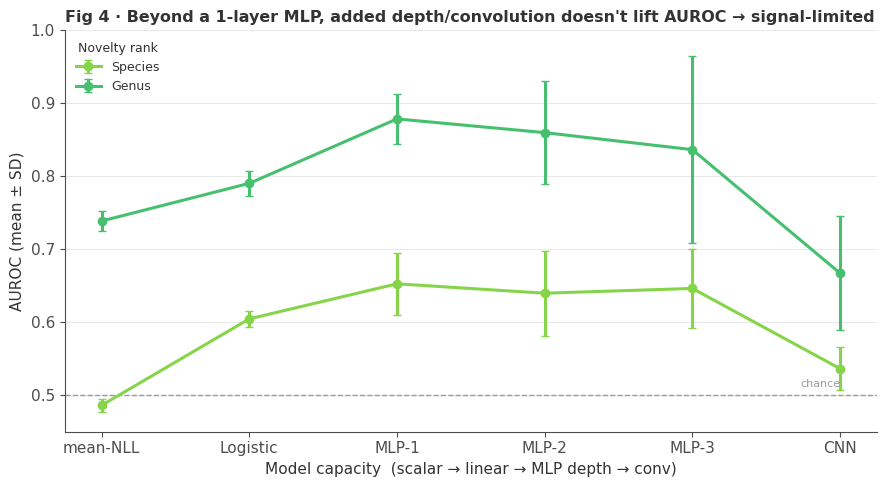

In [12]:
# Fig 4 — capacity ladder at Species & Genus (AUROC only; std_nll dropped; +MLP depth +CNN)
hard = ["Species", "Genus"]
rows = []
# (a) scalar + linear baselines from the repeated-CV summary
for mdl in ["mean_nll", "logistic_profile"]:
    s = summary[(summary.model==mdl) & (summary["rank"].astype(str).isin(hard))]
    for _, r in s.iterrows():
        rows.append(dict(model=mdl, rank=str(r["rank"]), auroc=r.auroc_mean, sd=r.auroc_sd))
# (b) MLP depth 1/2/3 from the depth-ablation summary (internally consistent CV)
dep_p = CP.OUT_ROOT / "depth_ablation" / "mlp_depth_ablation_summary.csv"
if dep_p.exists():
    d = pd.read_csv(dep_p)
    for depth in (1, 2, 3):
        for _, r in d[(d.depth==depth) & (d["rank"].isin(hard))].iterrows():
            rows.append(dict(model=f"mlp_d{depth}", rank=r["rank"], auroc=r.test_auroc_mean, sd=r.test_auroc_sd))
# (c) CNN (avg-pool) from this notebook's repeated-CV run
if len(cnn):
    cg = cnn[cnn.model=="cnn_avgpool"].groupby("rank").agg(m=("auroc","mean"), sd=("auroc","std"))
    for rk in hard:
        if rk in cg.index:
            rows.append(dict(model="cnn_avgpool", rank=rk, auroc=cg.loc[rk,"m"], sd=cg.loc[rk,"sd"]))
lad = pd.DataFrame(rows)
ladder = ["mean_nll","logistic_profile","mlp_d1","mlp_d2","mlp_d3","cnn_avgpool"]
xlab = {"mean_nll":"mean-NLL","logistic_profile":"Logistic","mlp_d1":"MLP-1","mlp_d2":"MLP-2",
        "mlp_d3":"MLP-3","cnn_avgpool":"CNN"}
present = [m for m in ladder if m in set(lad.model)]
x = np.arange(len(present))
fig, ax = plt.subplots(figsize=(9, 5))
for rk in hard:
    sub = lad[lad["rank"]==rk].set_index("model")
    y = [sub.loc[m,"auroc"] if m in sub.index else np.nan for m in present]
    e = [sub.loc[m,"sd"]    if m in sub.index else np.nan for m in present]
    ax.errorbar(x, y, yerr=e, marker="o", capsize=3, lw=2.2, color=RANK_COLOR[rk], label=rk)
ax.axhline(0.5, ls="--", c="#999", lw=1)
ax.text(x[-1], 0.508, "chance", color="#999", fontsize=8, va="bottom", ha="right")
ax.set_xticks(x); ax.set_xticklabels([xlab[m] for m in present])
despine(ax); ax.set_ylim(0.45, 1.0)
ax.set_xlabel("Model capacity  (scalar → linear → MLP depth → conv)")
ax.set_ylabel("AUROC (mean ± SD)")
ax.set_title("Fig 4 · Beyond a 1-layer MLP, added depth/convolution doesn't lift AUROC → signal-limited",
             loc="left", weight="bold", fontsize=11.5)
ax.legend(title="Novelty rank", loc="upper left", fontsize=9, title_fontsize=9)
fig.tight_layout(); fig.savefig(FIGS / "fig4_capacity_ladder.png", dpi=200, bbox_inches="tight"); plt.show()

### Fig 5 — what novelty is confused with (balanced multi-class)

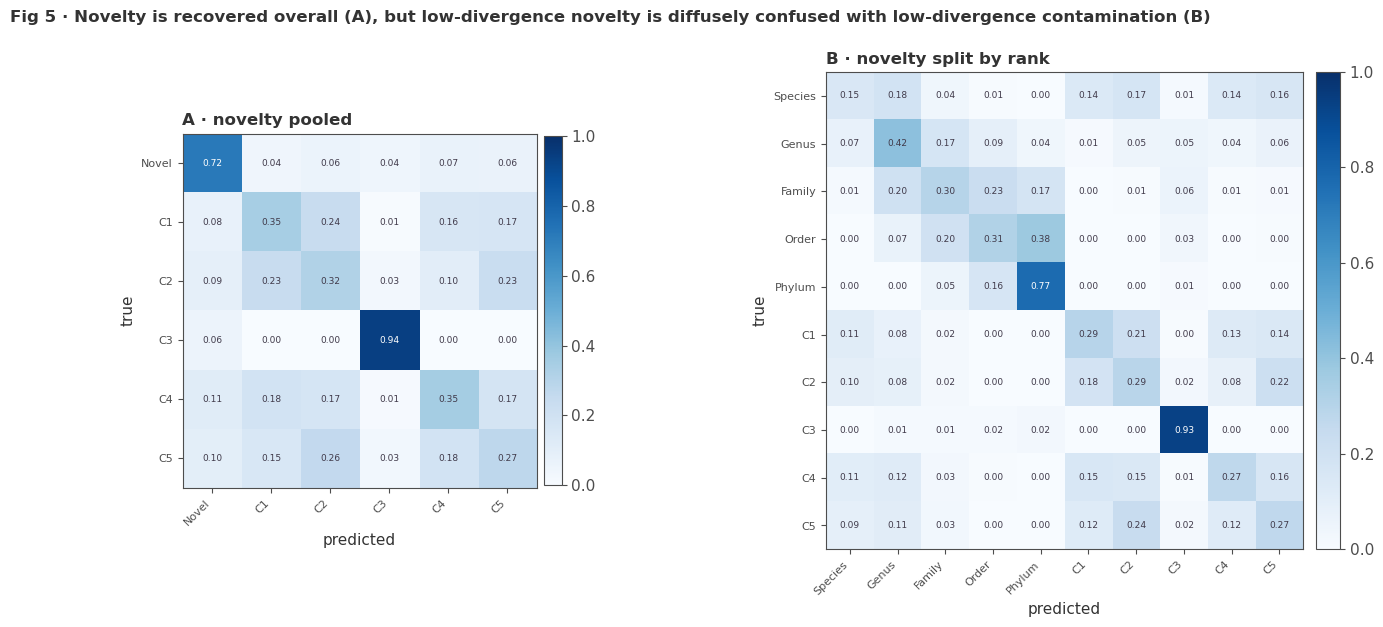

In [13]:
# Fig 5 — balanced multi-class confusion: A (novelty pooled) + B (novelty split by rank)
mcdir = CP.OUT_ROOT / "multiclass"
pa, pb = mcdir / "confusion_A_mlp_balanced.csv", mcdir / "confusion_B_mlp_balanced.csv"
if pa.exists() and pb.exists():
    A = pd.read_csv(pa, index_col=0); B = pd.read_csv(pb, index_col=0)
    fig = plt.figure(figsize=(15, 6.2))
    gs = fig.add_gridspec(1, 2, width_ratios=[len(A.columns), len(B.columns)], wspace=0.30)
    for k, (C, ttl) in enumerate([(A, "A · novelty pooled"), (B, "B · novelty split by rank")]):
        axn = fig.add_subplot(gs[k])
        im = axn.imshow(C.values, cmap="Blues", vmin=0, vmax=1)
        axn.set_xticks(range(len(C.columns))); axn.set_xticklabels(C.columns, rotation=45, ha="right", fontsize=8)
        axn.set_yticks(range(len(C.index)));   axn.set_yticklabels(C.index, fontsize=8)
        for i in range(C.shape[0]):
            for j in range(C.shape[1]):
                v = C.values[i, j]
                axn.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=6.5,
                         color="white" if v > 0.5 else "#403a4a")
        axn.set_xlabel("predicted"); axn.set_ylabel("true")
        axn.set_title(ttl, loc="left", weight="bold")
        fig.colorbar(im, ax=axn, fraction=0.046, pad=0.02)
    fig.suptitle("Fig 5 · Novelty is recovered overall (A), but low-divergence novelty is diffusely confused "
                 "with low-divergence contamination (B)", x=0.01, ha="left", weight="bold", fontsize=12)
    fig.savefig(FIGS / "fig5_confusion_AB.png", dpi=200, bbox_inches="tight"); plt.show()
else:
    print("balanced confusion CSVs not found — run reference_code/multiclass_quicktest.py (M4).")

In [14]:
mc_dir = CP.OUT_ROOT / "multiclass"
for f in ["confusion_A_mlp_balanced.csv", "confusion_B_mlp_balanced.csv"]:
    p = mc_dir / f
    if p.exists():
        print(f"\n{f}:"); print(pd.read_csv(p, index_col=0).round(3).to_string())
    else:
        print(f"{f} not found — run reference_code/multiclass_quicktest.py on the M4.")


confusion_A_mlp_balanced.csv:
       Novel     C1     C2     C3     C4     C5
Novel  0.718  0.042  0.062  0.045  0.070  0.065
C1     0.078  0.346  0.239  0.007  0.163  0.168
C2     0.086  0.235  0.316  0.027  0.104  0.232
C3     0.057  0.000  0.001  0.940  0.000  0.002
C4     0.114  0.184  0.170  0.008  0.352  0.173
C5     0.099  0.154  0.259  0.029  0.184  0.275

confusion_B_mlp_balanced.csv:
         Species  Genus  Family  Order  Phylum     C1     C2     C3     C4     C5
Species    0.149  0.185   0.036  0.006   0.002  0.140  0.169  0.013  0.140  0.160
Genus      0.072  0.415   0.172  0.088   0.038  0.010  0.050  0.054  0.038  0.063
Family     0.013  0.203   0.299  0.228   0.172  0.002  0.006  0.061  0.006  0.010
Order      0.000  0.068   0.199  0.314   0.377  0.000  0.002  0.034  0.002  0.004
Phylum     0.000  0.003   0.051  0.164   0.770  0.000  0.000  0.011  0.000  0.000
C1         0.114  0.078   0.018  0.002   0.001  0.294  0.215  0.004  0.130  0.144
C2         0.097  0.084   0.

## 6 · Reproducibility appendix

In [15]:
import sklearn
meta = {
    "repeat_seeds": REPEAT_SEEDS, "mlp_seeds": MLP_SEEDS, "n_splits": M.N_SPLITS,
    "error_bar": "mean ± SD across replicates (notes.md §1)",
    "replicate_def": "deterministic: repeat×fold (n=25); MLP: repeat×fold×seed (n=125)",
    "label_collision_groups": int(n_collision_groups),
    "python": platform.python_version(), "numpy": np.__version__,
    "pandas": pd.__version__, "sklearn": sklearn.__version__,
}
try:
    import torch; meta["torch"] = torch.__version__
    meta["device"] = ("cuda" if torch.cuda.is_available()
                      else "mps" if torch.backends.mps.is_available() else "cpu")
except ImportError:
    meta["torch"] = "absent (deterministic-only run)"
(OUT / "run_meta.json").write_text(json.dumps(meta, indent=2))
print(json.dumps(meta, indent=2))
print("\nArtifacts in", OUT)
for p in sorted(OUT.glob("*.csv")) + sorted(FIGS.glob("*.png")):
    print("  ", p.relative_to(OUT))

{
  "repeat_seeds": [
    42,
    101,
    202,
    303,
    404
  ],
  "mlp_seeds": [
    42,
    123,
    7,
    13,
    21
  ],
  "n_splits": 5,
  "error_bar": "mean \u00b1 SD across replicates (notes.md \u00a71)",
  "replicate_def": "deterministic: repeat\u00d7fold (n=25); MLP: repeat\u00d7fold\u00d7seed (n=125)",
  "label_collision_groups": 8,
  "python": "3.11.15",
  "numpy": "2.4.5",
  "pandas": "3.0.3",
  "sklearn": "1.8.0",
  "torch": "2.10.0",
  "device": "mps"
}

Artifacts in /Users/maiakaplan/Documents/evo2/nn_project/analysis_outputs/master_paper
   cnn_pooling_folds_repeated.csv
   lr_width_sensitivity.csv
   mlp_folds_repeated.csv
   per_rank_folds_repeated.csv
   per_rank_summary.csv
   qc_table.csv
   split_v2_seed101.csv
   split_v2_seed202.csv
   split_v2_seed303.csv
   split_v2_seed404.csv
   split_v2_seed42.csv
   training_curves_history.csv
   figures/fig1_per_rank_auroc.png
   figures/fig1_perbase_perplexity.png
   figures/fig2_mean_nll_overlap.png
   figures/fig

## 7 · Training-progress diagnostic — early-stopping curves (appendix)

In [16]:
# --- collect per-epoch history (history_sink) on the seed-42 partition, all ranks ---
hist_path = OUT / "training_curves_history.csv"
try:
    import torch  # noqa: F401
    df42 = M.build_frame(per_base, splits[42], collisions)
    hist = []
    for r in CP.ALL_POS_RANKS:
        if CP.primary_cohort(r) not in set(df42["cohort"]):
            continue
        M.eval_mlp(df42, r, seeds=MLP_SEEDS, history_sink=hist)        # logs tiny_mlp curves
        M.eval_cnn(df42, r, pool="avg", seeds=MLP_SEEDS, history_sink=hist)  # logs cnn_avgpool curves
    H = pd.DataFrame(hist)
    H.to_csv(hist_path, index=False)
    print(f"history rows: {len(H)}  ranks: {sorted(H['rank'].unique())}  (saved -> {hist_path.name})")
except ImportError:
    if hist_path.exists():
        H = pd.read_csv(hist_path); print(f"torch absent — reusing saved history ({len(H)} rows).")
    else:
        H = pd.DataFrame(); print("torch absent and no saved history — run this cell on the M4.")

history rows: 59949  ranks: ['Family', 'Genus', 'Noise', 'Novelty', 'Order', 'Phylum', 'Species']  (saved -> training_curves_history.csv)


saved -> figS_training_curves.png


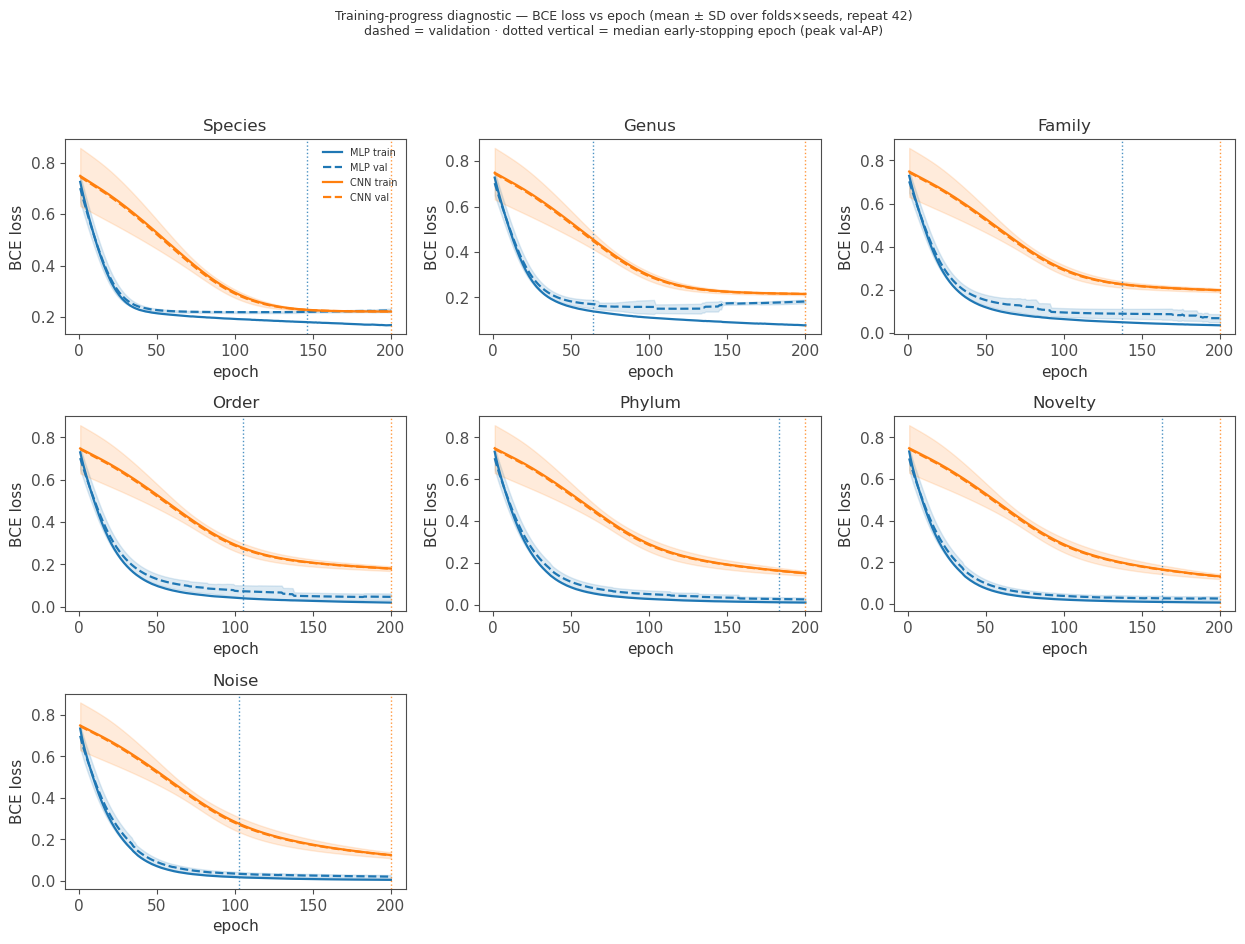

In [17]:
# --- figS: learning curves per rank (train solid / val dashed, mean ± SD over folds×seeds) ---
if len(H):
    ranks_present = [r for r in CP.RANK_ORDER if r in set(H["rank"])]
    models = [("tiny_mlp", "tab:blue", "MLP"), ("cnn_avgpool", "tab:orange", "CNN")]
    ncol = min(3, len(ranks_present)); nrow = int(np.ceil(len(ranks_present) / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(4.2 * ncol, 3.2 * nrow), squeeze=False)
    for ax, rank in zip(axes.ravel(), ranks_present):
        sub = H[H["rank"] == rank]
        for model, color, label in models:
            g = sub[sub["model"] == model]
            if not len(g):
                continue
            agg = (g.groupby("epoch")
                     .agg(tr_m=("train_loss", "mean"),
                          va_m=("val_loss", "mean"), va_s=("val_loss", "std"),
                          n=("train_loss", "size")))
            agg = agg[agg["n"] >= 3]            # only epochs reached by >=3 runs (ragged tails)
            ep = agg.index.values
            ax.plot(ep, agg["tr_m"], color=color, lw=1.6, label=f"{label} train")
            ax.plot(ep, agg["va_m"], color=color, lw=1.6, ls="--", label=f"{label} val")
            ax.fill_between(ep, agg["va_m"] - agg["va_s"], agg["va_m"] + agg["va_s"],
                            color=color, alpha=0.15)
            # early-stop marker follows each model's actual selection criterion:
            # MLP selects on val-AP (argmax); CNN selects on val-loss (argmin).
            if model.startswith("cnn"):
                idx = g.groupby(["fold", "seed"])["val_loss"].idxmin()
            else:
                idx = g.groupby(["fold", "seed"])["val_ap"].idxmax()
            best_ep = g.loc[idx, "epoch"]
            ax.axvline(np.median(best_ep), color=color, ls=":", lw=1.0, alpha=0.8)  # median early-stop
        ax.set_title(rank); ax.set_xlabel("epoch"); ax.set_ylabel("BCE loss")
    for ax in axes.ravel()[len(ranks_present):]:
        ax.set_visible(False)
    axes.ravel()[0].legend(fontsize=7, loc="upper right")
    fig.suptitle("Training-progress diagnostic — BCE loss vs epoch (mean ± SD over folds×seeds, repeat 42)\n"
                 "dashed = validation · dotted vertical = median early-stopping epoch (peak val-AP)",
                 fontsize=9)
    fig.tight_layout(rect=[0, 0, 1, 0.93])
    fig.savefig(FIGS / "figS_training_curves.png", dpi=200, bbox_inches="tight")
    print("saved ->", (FIGS / "figS_training_curves.png").name)
    plt.show()
else:
    print("no history to plot — run the collection cell on the M4 first.")

## 8 · Precision–Recall curves at the hard ranks (appendix)

saved -> figS2_pr_curves.png


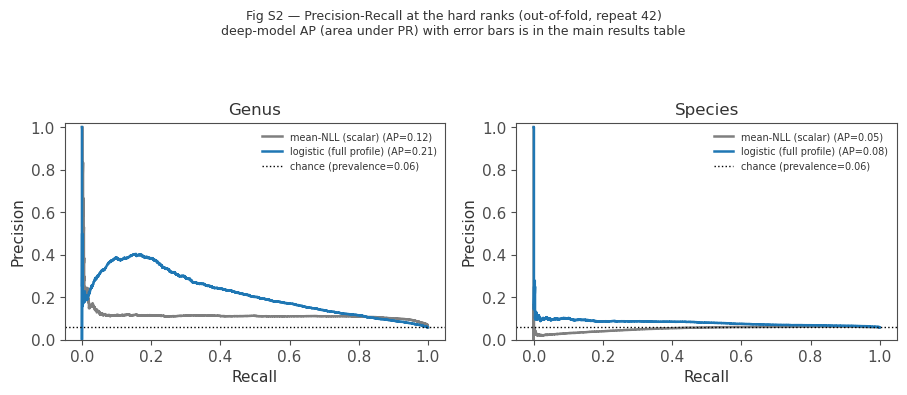

In [18]:
# --- figS2: out-of-fold Precision-Recall at the hard ranks (deterministic, runs anywhere) ---
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

df42 = M.build_frame(per_base, splits[42], collisions)
pr_ranks = [r for r in ["Genus", "Species"] if CP.primary_cohort(r) in set(df42["cohort"])]
fig, axes = plt.subplots(1, len(pr_ranks), figsize=(4.6 * len(pr_ranks), 4.0), squeeze=False)
for ax, rank in zip(axes.ravel(), pr_ranks):
    pos = df42[df42["cohort"] == CP.primary_cohort(rank)]
    neg = df42[~df42["is_pos"]]
    task = pd.concat([pos, neg], ignore_index=True)
    y = task["cohort"].eq(CP.primary_cohort(rank)).astype(int).to_numpy()
    X = np.vstack(task["nll"].to_numpy()).astype(np.float32)
    fold = task["fold"].to_numpy()
    s_scalar = np.full(len(y), np.nan)   # mean-NLL: higher = more novel
    s_logit  = np.full(len(y), np.nan)   # logistic P(novelty), refit per fold
    for f in sorted(np.unique(fold)):
        te = fold == f; tr = ~te
        if y[te].sum() == 0 or y[tr].sum() == 0:
            continue
        s_scalar[te] = task.loc[te, "mean_nll"].to_numpy()
        lr = Pipeline([("sc", StandardScaler()),
                       ("lr", LogisticRegression(max_iter=4000, class_weight="balanced",
                                                 random_state=42))])
        lr.fit(X[tr], y[tr])
        s_logit[te] = lr.predict_proba(X[te])[:, 1]
    prev = float(y.mean())
    for score, color, name in [(s_scalar, "tab:gray", "mean-NLL (scalar)"),
                               (s_logit,  "tab:blue", "logistic (full profile)")]:
        m = ~np.isnan(score)
        p, r, _ = precision_recall_curve(y[m], score[m])
        apv = average_precision_score(y[m], score[m])
        ax.plot(r, p, color=color, lw=1.8, label=f"{name} (AP={apv:.2f})")
    ax.axhline(prev, color="k", ls=":", lw=1.0, label=f"chance (prevalence={prev:.2f})")
    ax.set_xlabel("Recall"); ax.set_ylabel("Precision"); ax.set_title(rank)
    ax.set_ylim(0, 1.02); ax.legend(fontsize=7, loc="upper right")
fig.suptitle("Fig S2 — Precision-Recall at the hard ranks (out-of-fold, repeat 42)\n"
             "deep-model AP (area under PR) with error bars is in the main results table", fontsize=9)
fig.tight_layout(rect=[0, 0, 1, 0.90])
fig.savefig(FIGS / "figS2_pr_curves.png", dpi=200, bbox_inches="tight")
print("saved ->", (FIGS / "figS2_pr_curves.png").name)
plt.show()

## 9 · Hyperparameter sensitivity — lr × width (appendix)

In [19]:
# --- collect lr x width sweep for the MLP at one hard rank (repeat 42) ---
sens_path = OUT / "lr_width_sensitivity.csv"
SWEEP_RANK  = "Genus"
LRS         = [3e-4, 1e-3, 3e-3]
WIDTHS      = [32, 64, 128]
SWEEP_SEEDS = [42, 123, 7]          # 3 seeds keeps the appendix cheap; bump to MLP_SEEDS if desired
try:
    import torch
    from torch import nn
    from sklearn.metrics import average_precision_score, roc_auc_score
    dfS = M.build_frame(per_base, splits[42], collisions)
    pos = dfS[dfS["cohort"] == CP.primary_cohort(SWEEP_RANK)]
    neg = dfS[~dfS["is_pos"]]
    task = pd.concat([pos, neg], ignore_index=True)
    y = task["cohort"].eq(CP.primary_cohort(SWEEP_RANK)).astype(int).to_numpy()
    Xall = np.vstack(task["nll"].to_numpy()).astype(np.float32)
    folds = task["fold"].to_numpy(); uniq = sorted(np.unique(folds))
    dev = ("cuda" if torch.cuda.is_available()
           else "mps" if torch.backends.mps.is_available() else "cpu")

    def train_eval(width, lr, Xtr, ytr, Xva, yva_np, Xte, yte_np, seed):
        """Same recipe as M.eval_mlp, but width and lr are parameters."""
        torch.manual_seed(seed); np.random.seed(seed)
        net = nn.Sequential(nn.Linear(Xtr.shape[1], width), nn.ReLU(),
                            nn.Dropout(0.10), nn.Linear(width, 1)).to(dev)
        opt = torch.optim.Adam(net.parameters(), lr=lr); lossf = nn.BCEWithLogitsLoss()
        xtr = torch.tensor(Xtr, device=dev); ytr_t = torch.tensor(ytr, dtype=torch.float32, device=dev)
        xva = torch.tensor(Xva, device=dev)
        best_ap, best_state, bad = -1.0, None, 0
        for _ in range(200):
            net.train(); opt.zero_grad()
            loss = lossf(net(xtr).squeeze(-1), ytr_t); loss.backward(); opt.step()
            net.eval()
            with torch.no_grad():
                vp = torch.sigmoid(net(xva).squeeze(-1)).cpu().numpy()
            ap = average_precision_score(yva_np, vp) if yva_np.sum() else 0.0
            if ap > best_ap:
                best_ap, bad = ap, 0
                best_state = {k: v.clone() for k, v in net.state_dict().items()}
            else:
                bad += 1
                if bad >= 25:
                    break
        if best_state:
            net.load_state_dict(best_state)
        net.eval()
        with torch.no_grad():
            tp = torch.sigmoid(net(torch.tensor(Xte, device=dev)).squeeze(-1)).cpu().numpy()
        return float(roc_auc_score(yte_np, tp))

    rows = []
    for test_fold in uniq:
        val_fold = uniq[(uniq.index(test_fold) + 1) % len(uniq)]
        test = folds == test_fold; val = folds == val_fold; train = ~(test | val)
        if y[test].sum() == 0 or y[train].sum() == 0:
            continue
        mu, sd = Xall[train].mean(0, keepdims=True), Xall[train].std(0, keepdims=True) + 1e-6
        Xtr, Xva, Xte = (Xall[train]-mu)/sd, (Xall[val]-mu)/sd, (Xall[test]-mu)/sd
        for width in WIDTHS:
            for lr in LRS:
                for seed in SWEEP_SEEDS:
                    au = train_eval(width, lr, Xtr, y[train], Xva, y[val], Xte, y[test], seed)
                    rows.append({"width": width, "lr": lr, "fold": int(test_fold),
                                 "seed": seed, "auroc": au})
    S = pd.DataFrame(rows); S.to_csv(sens_path, index=False)
    print(f"sensitivity rows: {len(S)}  (saved -> {sens_path.name})")
except ImportError:
    S = pd.read_csv(sens_path) if sens_path.exists() else pd.DataFrame()
    print("torch absent —" + (f" reusing {len(S)} saved rows." if len(S) else " run this cell on the M4."))

sensitivity rows: 135  (saved -> lr_width_sensitivity.csv)


AUROC spread across grid: 0.046
lr     0.0003  0.0010  0.0030
width                        
32      0.840   0.882   0.879
64      0.882   0.884   0.879
128     0.886   0.882   0.877


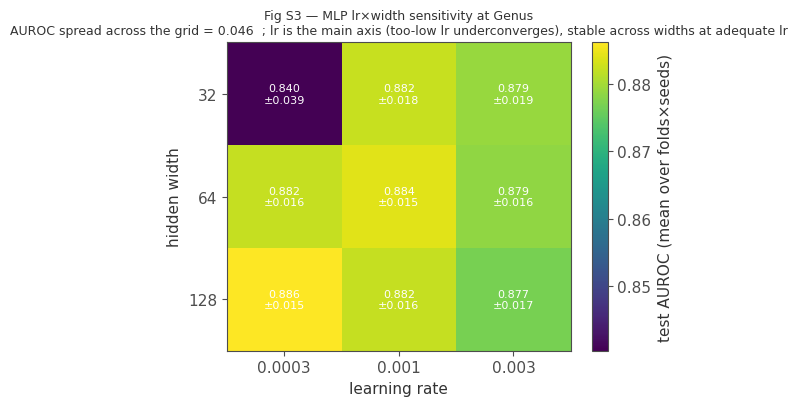

In [20]:
# --- figS3: lr x width AUROC heatmap + grid spread ---
if len(S):
    piv_m = S.groupby(["width", "lr"])["auroc"].mean().unstack("lr")
    piv_s = S.groupby(["width", "lr"])["auroc"].std().unstack("lr")
    spread = float(piv_m.values.max() - piv_m.values.min())
    fig, ax = plt.subplots(figsize=(5.4, 4.2))
    im = ax.imshow(piv_m.values, cmap="viridis", aspect="auto")
    ax.set_xticks(range(piv_m.shape[1])); ax.set_xticklabels([f"{c:g}" for c in piv_m.columns])
    ax.set_yticks(range(piv_m.shape[0])); ax.set_yticklabels(piv_m.index)
    ax.set_xlabel("learning rate"); ax.set_ylabel("hidden width")
    for i in range(piv_m.shape[0]):
        for j in range(piv_m.shape[1]):
            ax.text(j, i, f"{piv_m.values[i, j]:.3f}\n±{piv_s.values[i, j]:.3f}",
                    ha="center", va="center", color="w", fontsize=8)
    fig.colorbar(im, ax=ax, label="test AUROC (mean over folds×seeds)")
    ax.set_title(f"Fig S3 — MLP lr×width sensitivity at {SWEEP_RANK}\n"
                 f"AUROC spread across the grid = {spread:.3f}  ; lr is the main axis (too-low lr underconverges), stable across widths at adequate lr",
                 fontsize=9)
    fig.tight_layout()
    fig.savefig(FIGS / "figS3_lr_width_sensitivity.png", dpi=200, bbox_inches="tight")
    print(f"AUROC spread across grid: {spread:.3f}")
    print(piv_m.round(3))
    plt.show()
else:
    print("no sensitivity data to plot — run the sweep cell on the M4 first.")